<a href="https://colab.research.google.com/github/Kshitiz-hub-ops/assignment-02-bitsom_ba_2511399/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Success! Generated embeddings shape: (10, 384)



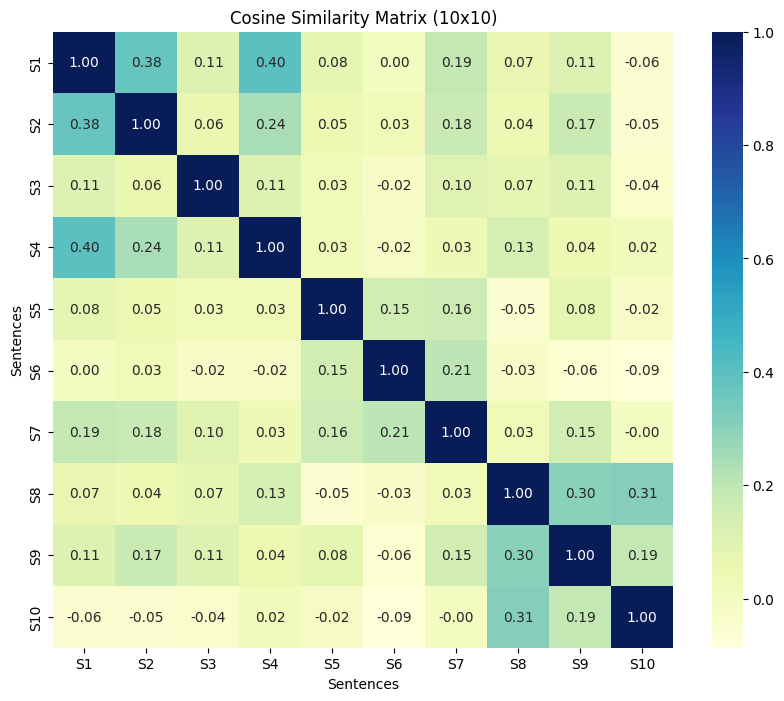

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Write 10 sentences across 3 topics (Cricket, Cooking, Cybersecurity)
sentences = [
    # Topic 1: Cricket (4 sentences)
    "The batsman hit a massive six over long-on.",
    "A fast yorker shattered the stumps.",
    "The team won the world cup finals.",
    "Fielding restrictions apply in the first ten overs.",

    # Topic 2: Cooking (3 sentences)
    "Bake the chocolate cake in the oven for thirty minutes.",
    "Add salt and freshly ground black pepper to taste.",
    "The chef chopped the onions finely for the curry.",

    # Topic 3: Cybersecurity (3 sentences)
    "A strong firewall protects the network from malicious attacks.",
    "The hacker used phishing emails to steal user passwords.",
    "Encrypting sensitive data ensures privacy and compliance."
]

# 2. Generate embeddings using all-MiniLM-L6-v2
print("Downloading and loading the model (might take a few seconds)...")
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print(f"Success! Generated embeddings shape: {embeddings.shape}\n")

# 3. Compute and display a 10x10 cosine similarity matrix as a heatmap
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="YlGnBu", fmt=".2f",
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)])
plt.title("Cosine Similarity Matrix (10x10)")
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.show()

In [3]:
# 4. Given a new query sentence, find the top 2 most similar sentences
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

# Calculate similarity between query and all 10 base sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get indices of top 2 highest scores
top_2_indices = np.argsort(query_similarities)[-2:][::-1]

print(f"QUERY: '{query}'\n")
print("--- TOP 2 MOST SIMILAR SENTENCES ---")
for rank, idx in enumerate(top_2_indices):
    print(f"Rank {rank+1}: '{sentences[idx]}'")
    print(f"Similarity Score: {query_similarities[idx]:.4f}\n")

QUERY: 'The bowler took three wickets in one over'

--- TOP 2 MOST SIMILAR SENTENCES ---
Rank 1: 'The batsman hit a massive six over long-on.'
Similarity Score: 0.5465

Rank 2: 'Fielding restrictions apply in the first ten overs.'
Similarity Score: 0.4244

